# Cortex layer sweep

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [2]:
import re

dataset_name = 'cortex'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/LIBD/sce_DLPFC_annotated_signature_matrix_broad_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/LIBD/rse_id.csv'
ground_truth_path = '/nfs/home/rfu/projects/deconv_language/libd_groundtruth.csv'

signature_df = pd.read_csv(reference_path, index_col=0)
signature_df = signature_df.T
bulk_df = pd.read_csv(bulk_path, index_col=0)

#bulk_df.index = gene_id_name_map(gene_list=bulk_df.index, mode='to_ensembl')
#bulk_df = bulk_df.loc[bulk_df.index.dropna()]
ground_truth = pd.read_csv(ground_truth_path, index_col=0)
ground_truth = ground_truth[ground_truth.type != "Other"]
ground_truth = ground_truth.reset_index()

In [3]:
ground_truth = ground_truth.pivot(index="tissue", values="groundtruth", columns="type")
ground_truth = ground_truth.fillna(0)
ground_truth.index.name = None
ground_truth.columns.name = None

In [4]:
bulk_df = bulk_df[bulk_df.index.str.endswith("_Bulk")]

In [5]:
import pandas as pd
from collections import defaultdict


def match_to_groundtruth(results, ground_truth, verbose=True):
    """Align deconvolution results to ground truth by donor.

    Matches on donor ID (Br####) parsed from the results index. An exact
    donor_region match wins; otherwise falls back to the donor's single
    ground truth row. Rows that are ambiguous (donor has multiple gt rows,
    none matching on region) or have no gt donor are dropped.

    Returns (results_matched, gt_matched) sharing an index and columns.
    """
    donor = results.index.str.extract(r"_(Br\d+)_", expand=False).str.lower()
    region = results.index.str.extract(r"_Br\d+_([A-Za-z]+)_", expand=False).str.lower()
    exact = donor + "_" + region

    rows_by_donor = defaultdict(list)
    for name, d in zip(ground_truth.index, ground_truth.index.str.extract(r"^(br\d+)", expand=False)):
        rows_by_donor[d].append(name)

    picked, ambiguous, unmatched = [], [], []
    for name, d, k in zip(results.index, donor, exact):
        cands = rows_by_donor.get(d, [])
        if k in ground_truth.index:
            picked.append(k)
        elif len(cands) == 1:
            picked.append(cands[0])
        else:
            picked.append(None)
            (ambiguous if cands else unmatched).append((name, cands))

    picked = pd.Series(picked, index=results.index)
    mask = picked.notna()

    if verbose:
        print(f"matched {mask.sum()} of {len(mask)}")
        if ambiguous:
            print("ambiguous (multiple gt rows, no region match):", ambiguous)
        if unmatched:
            print("no gt donor at all:", unmatched)

    res = results[mask.values]
    gt = ground_truth.reindex(picked[mask].values)
    gt.index = res.index

    cols = [c for c in res.columns if c in gt.columns]
    return res[cols], gt[cols]

In [6]:
def harmonize_columns(df):
    df = df.copy()
    if 'Oligo' in df.columns and 'OPC' in df.columns:
        df['OligoOPC'] = df['Oligo'] + df['OPC']
        df = df.drop(columns=['Oligo', 'OPC'])
    return df

In [7]:
bulk_df.shape

(38, 21745)

### Zeroshot

In [8]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        #samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P, T = match_to_groundtruth(df, ground_truth)
        #P = P.loc[samples, celltypes].astype(float)
        #T = T.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_zeroshot_cortex_all_samples.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.57it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


...

Loading Geneformer model...
Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 13.58.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1833.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9522.
Most similar pair: Excit vs Inhib.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.03 seconds.
Running solver: simplex
Finished in 0.03 seconds.
Running solver: ridge_simplex
Finished in 0.03 seconds.
Running solver: dwls_simplex
Finished in 0.06 seconds.
Running solver: ridge
Finished in 0.02 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 1.00 seconds.
Running solver: simplex_nnls
Finished in 0.02 seconds.
Running solver: gradient_descent

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.40 seconds.
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38


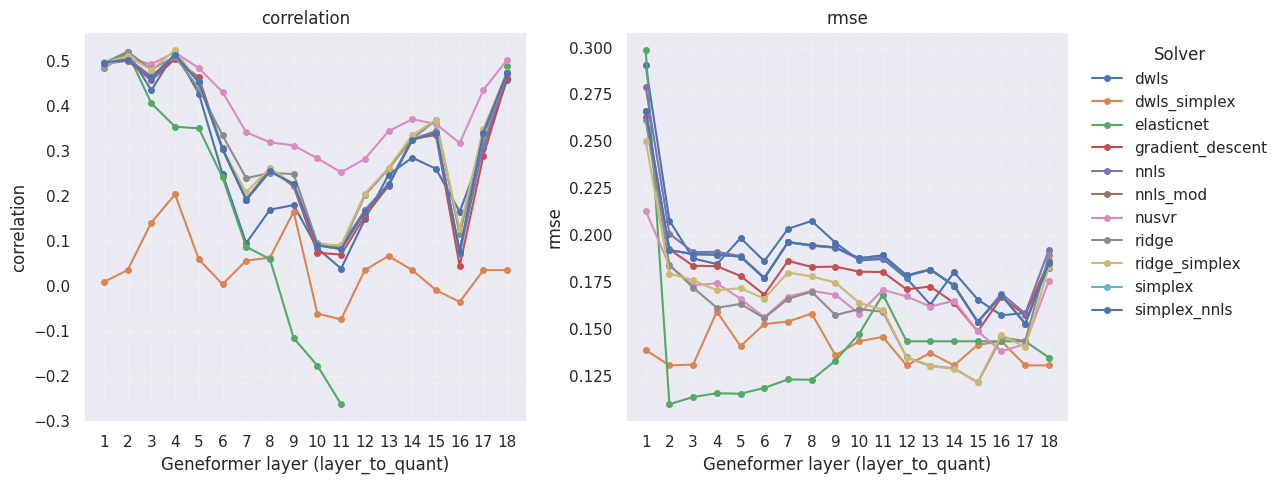

    layer            solver  correlation      rmse  meanCorrelation  meanRMSE
13      2              dwls     0.519523  0.207781         0.040635  0.163837
38      4      dwls_simplex     0.202890  0.159237        -0.045566  0.145805
18      2        elasticnet     0.517507  0.109809         0.021800  0.105508
43      4  gradient_descent     0.503619  0.183405         0.012743  0.148810
33      4              nnls     0.512368  0.191063         0.038141  0.157725
34      4          nnls_mod     0.512531  0.189571         0.037895  0.157091
41      4             nusvr     0.518384  0.174308         0.040554  0.142977
17      2             ridge     0.520072  0.184125         0.028624  0.150994
37      4     ridge_simplex     0.523445  0.170591         0.058654  0.142564
36      4           simplex     0.512531  0.189570         0.065759  0.157091
42      4      simplex_nnls     0.512531  0.189571         0.044632  0.157091


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_zeroshot_cortex_all_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

### Fine-tuned Model

In [10]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/LIBD/geneformer/complete/finetuned316m/260213_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/LIBD/geneformer/complete/finetuned316m/260213_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        #samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P, T = match_to_groundtruth(df, ground_truth)
        #P = df.loc[samples, celltypes].astype(float)
        #T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_finetuned_cortex_all_samples.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.83it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/LIBD/geneformer/complete/finetuned316m/260213_geneformer_cellClassifier_cell_annot_subset/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


...

Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 5.02.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.4122.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.8159.
Most similar pair: Excit vs Inhib.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.03 seconds.
Running solver: simplex
Finished in 0.04 seconds.
Running solver: ridge_simplex
Finished in 0.04 seconds.
Running solver: dwls_simplex
Finished in 0.07 seconds.
Running solver: ridge
Finished in 0.02 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 1.01 seconds.
Running solver: simplex_nnls
Finished in 0.02 seconds.
Running solver: gradient_descent


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.40 seconds.
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38
matched 38 of 38


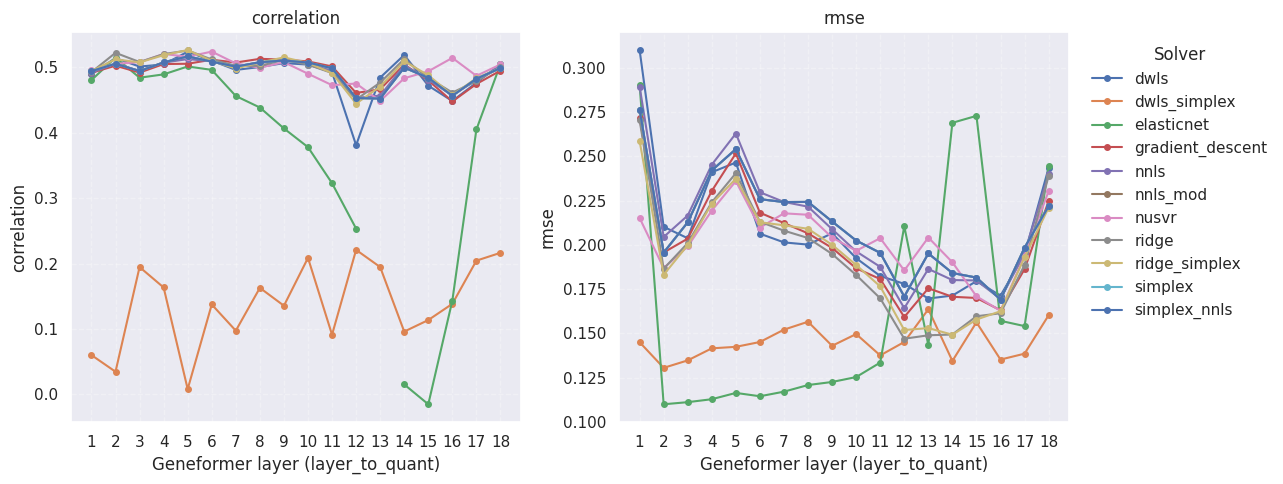

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
46       5              dwls     0.523907  0.246585         0.072113  0.177980
126     12      dwls_simplex     0.220976  0.145168         0.075193  0.136764
18       2        elasticnet     0.514930  0.109968         0.033103  0.106122
87       8  gradient_descent     0.512996  0.206572         0.080548  0.153555
44       5              nnls     0.512659  0.262972         0.061291  0.182013
45       5          nnls_mod     0.516708  0.254159         0.059820  0.178723
63       6             nusvr     0.524081  0.209807         0.076476  0.156243
50       5             ridge     0.525789  0.240539         0.085696  0.171309
48       5     ridge_simplex     0.526461  0.237425         0.089474  0.170805
47       5           simplex     0.516709  0.254158         0.054982  0.178723
53       5      simplex_nnls     0.516709  0.254158        -0.021341  0.178723


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_finetuned_cortex_all_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

## Visualize all results 

In [12]:
# import glob
# import os
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Set the visual style to have a white background
# sns.set_theme(style="white", palette="muted")

# directory_path = '/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/results/gf_layer_sweep/'
# all_files = glob.glob(os.path.join(directory_path, "*.csv"))

# df_list = []
# for filename in all_files:
#     try:
#         df = pd.read_csv(filename)
#         df = df[df.layer == 18]
#         df_list.append(df)
#     except Exception as e:
#         print(f"Error reading {filename}: {e}")

# # Combine all dataframes into a single dataframe
# if df_list:
#     combined_df = pd.concat(df_list, ignore_index=True)
    
#     # Verify columns exist
#     expected_columns = ['layer', 'solver', 'correlation', 'rmse', 'meanCorrelation', 'meanRMSE']
#     missing_cols = [col for col in expected_columns if col not in combined_df.columns]
    
#     if missing_cols:
#         print(f"Warning: The following expected columns are missing from the data: {missing_cols}")
    
#     target_y_column = 'correlation' 
    
#     plt.figure(figsize=(10, 4))
    
#     # Create the box plot (fliersize=0 avoids duplicate outliers if showing all points)
#     sns.boxplot(x='solver', y=target_y_column, data=combined_df, fliersize=0, boxprops=dict(alpha=0.8))
    
#     # Overlay individual data points
#     #sns.stripplot(x='layer', y=target_y_column, data=combined_df, color='black', alpha=0.5, jitter=0.2, size=4)
    
#     plt.title(f'{target_y_column} by layer', fontsize=14)
#     #plt.xlabel('Layer', fontsize=12)
#     plt.ylabel(target_y_column, fontsize=12)
#     plt.xticks(rotation=45)
    
#     # Optional: Add gridlines for easier reading on a white background
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
    
#     plt.tight_layout()
    
#     # Show the plot
#     plt.show()
# else:
#     print("No CSV files found in the specified directory.")